In [94]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import seaborn as sns

In [85]:
dataset_path = "../dataset"
print(os.listdir(dataset_path))

['README.roboflow.txt', 'valid', 'README.dataset.txt', '.DS_Store', 'test', 'data.yaml', 'train']


In [86]:
import yaml

with open(f"{dataset_path}/data.yaml", "r") as f:
    data = yaml.safe_load(f)

print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 6, 'names': ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches'], 'roboflow': {'workspace': 'neudefectdetection', 'project': 'neu-surface-defect-pohqa', 'version': 1, 'license': 'Public Domain', 'url': 'https://universe.roboflow.com/neudefectdetection/neu-surface-defect-pohqa/dataset/1'}}


In [87]:
class_names = data['names']
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of classes: 6


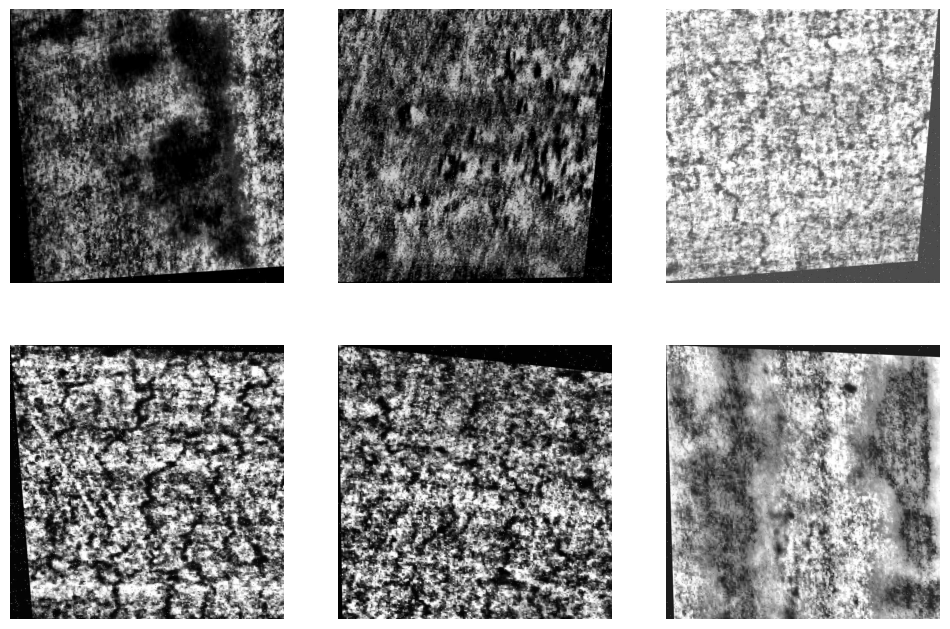

In [88]:
def show_sample_images(folder, n=6):
    image_folder = os.path.join(dataset_path, folder, "images")
    images = os.listdir(image_folder)

    plt.figure(figsize=(12,8))

    for i in range(n):
        img_name = random.choice(images)
        img_path = os.path.join(image_folder, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

show_sample_images("train")


In [89]:
def show_labeled_image(img_path, label_path, class_names):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            labels = f.readlines()

        for label in labels:
            cls, x, y, bw, bh = map(float, label.split())

            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
            cv2.putText(img, class_names[int(cls)], (x1,y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

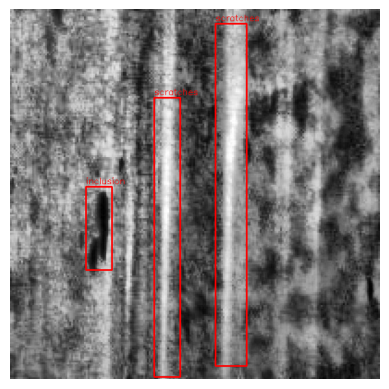

In [90]:
img_path = f"{dataset_path}/train/images/" + os.listdir(f"{dataset_path}/train/images")[0]
label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")

show_labeled_image(img_path, label_path, class_names)

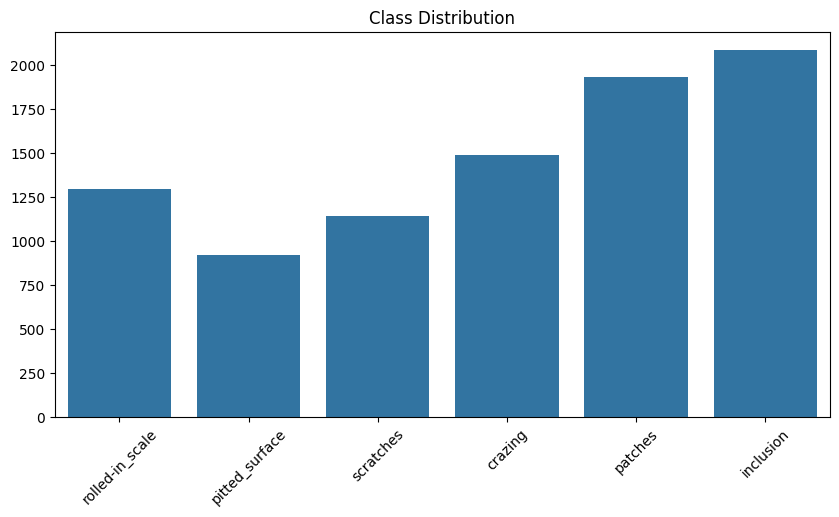

In [91]:
label_dir = f"{dataset_path}/train/labels"

class_count = {}

for file in os.listdir(label_dir):
    with open(os.path.join(label_dir, file), "r") as f:
        for line in f:
            cls = int(line.split()[0])
            class_count[cls] = class_count.get(cls, 0) + 1

# Convert to names
labels = [class_names[k] for k in class_count.keys()]
values = list(class_count.values())

plt.figure(figsize=(10,5))
sns.barplot(x=labels, y=values)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [92]:
model = YOLO("yolov8n.pt")

In [95]:
results = model.train(
    data=f"{dataset_path}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="defect_detection_yolov8"
)

Ultralytics 8.4.66 🚀 Python-3.12.4 torch-2.2.2 CPU (Intel Core i7-9750H 2.60GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=defect_detection_yolov8-7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

RuntimeError: Numpy is not available